In [1]:
from scipy.sparse import load_npz
import pandas as pd
import json
import jsonlines

In [2]:
with jsonlines.open("data/application/ukiyoe/metadata.jsonl") as reader:
    metadata = [line for line in reader]

idx2image_name = dict()
image_name2idx = dict()
for i, meta in enumerate(metadata):
    idx2image_name[i] = meta["id"]
    image_name2idx[meta["id"]] = i

In [3]:
annotations = pd.read_csv("data/assets/ukiyoe/full_dataset/data_clean.csv")
annotations

,idx,img,artist,date,era,source,similars,label
0,0,0.jpg,Okumura Masanobu,1711,Early Ukiyo-e (Early-Mid 1700s),British Museum,['0'],0
1,1,1.jpg,Okumura Masanobu,1740,Early Ukiyo-e (Early-Mid 1700s),Museum of Fine Arts,['1'],1
2,2,2.jpg,Okumura Masanobu,1715,Early Ukiyo-e (Early-Mid 1700s),Library of Congress,['2'],2
3,3,3.jpg,Okumura Masanobu,1686,Early Ukiyo-e (Early-Mid 1700s),British Museum,['3'],3
4,4,4.jpg,Okumura Masanobu,0,Early Ukiyo-e (Early-Mid 1700s),Museum of Fine Arts,['4'],4
...,...,...,...,...,...,...,...,...
177892,178789,178789.jpg,Kusaka Kenji,1950,Modern and Contemporary (1950s to Now),Artelino,"['178760', '178773', '178789', '178792']",158645
177893,178790,178790.jpg,Kusaka Kenji,1950,Modern and Contemporary (1950s to Now),Artelino,"['178711', '178716', '178752', '178762', '1787...",158593
177894,178791,178791.jpg,Kusaka Kenji,1949,Modern and Contemporary (1950s to Now),Artelino,"['178725', '178791']",158646
177895,178792,178792.jpg,Kusaka Kenji,1948,Modern and Contemporary (1950s to Now),Artelino,"['178773', '178789', '178792']",158638


In [4]:
idx2era = dict()

for _, row in annotations.iterrows():
    idx2era[image_name2idx[row["img"]]] = row["era"]

In [5]:
theta = load_npz("results/interpret_sae/ukiyoe/text/theta_csr.npz")

In [6]:
with open("data/application/ukiyoe/topics/text/cluster_to_feature_indices.json", "r") as f:
    cluster_to_feature_indices = json.load(f)

feature_idx_to_cluster = dict()
for cluster_id, feature_indices in cluster_to_feature_indices.items():
    for feature_idx in feature_indices:
        feature_idx_to_cluster[feature_idx] = cluster_id

In [7]:
from collections import defaultdict
from tqdm.notebook import trange, tqdm

era_cluster_id_counts = defaultdict(lambda: defaultdict(set))

for i, feature_idx in tqdm(zip(*theta.nonzero()), total=theta.nnz):
    cluster_id = feature_idx_to_cluster[feature_idx]
    era_cluster_id_counts[idx2era[i]][cluster_id].add(i)

  0%|          | 0/5256375 [00:00<?, ?it/s]

In [8]:
era_cluster_id_counts = {
    era: {cluster_id: len(count) for cluster_id, count in era_cluster_id_counts[era].items()}
    for era in era_cluster_id_counts.keys()
}

In [9]:
era_counts = annotations["era"].value_counts()

In [10]:
era_cluster_id_ratios = {
    era: {cluster_id: count / era_counts[era] for cluster_id, count in era_cluster_id_counts[era].items()}
    for era in era_counts.keys()
}

In [11]:
era_cluster_id_ratio_records = []
for era in era_counts.keys():
    for cluster_id, ratio in era_cluster_id_ratios[era].items():
        era_cluster_id_ratio_records.append({
            "era": era,
            "cluster_id": cluster_id,
            "ratio": ratio
        })

era_cluster_id_ratio_df = pd.DataFrame(era_cluster_id_ratio_records)

In [14]:
era_order = [
    "Birth of Full-Color Printing (1740s to 1780s)",
    "Early Ukiyo-e (Early-Mid 1700s)",
    "Golden Age of Ukiyo-e (1780 to 1804)",
    "Popularization of Woodblock Printing (1804 to 1868)",
    "Meiji Period (1868 to 1912)",
    "Shin Hanga and Sosaku Hanga Movements (1915 to 1940s)",
    "Modern and Contemporary (1950s to Now)"
]

In [15]:
cluster_annotations = pd.read_csv("data/application/ukiyoe/topics/text/clusters_annotated.csv")

cluster_id_to_summary = dict()
cluster_id_to_mode = dict()

for _, row in cluster_annotations.iterrows():
    cluster_id_to_summary[str(row["cluster_id"])] = row["llm_summary"]
    cluster_id_to_mode[str(row["cluster_id"])] = row["llm_classification"]

In [16]:
table = era_cluster_id_ratio_df.pivot(index="cluster_id", columns="era", values="ratio")
table = table[era_order]
# Add column with variance of the ratios
table["variance"] = table.var(axis=1)
table["mean"] = table[era_order].mean(axis=1)
# Remove rows with mean > 0.5
table = table[table["mean"] <= 0.3]
# Add column with cluster summary
table["summary"] = [cluster_id_to_summary[cluster_id] for cluster_id in table.index]
# Add column with cluster mode
table["mode"] = [cluster_id_to_mode[cluster_id] for cluster_id in table.index]
# Remove rows with mode = "abstract"
table = table[table["mode"] != "abstract"]
table.sort_values(by="variance", ascending=False).head(10)

era,Birth of Full-Color Printing (1740s to 1780s),Early Ukiyo-e (Early-Mid 1700s),Golden Age of Ukiyo-e (1780 to 1804),Popularization of Woodblock Printing (1804 to 1868),Meiji Period (1868 to 1912),Shin Hanga and Sosaku Hanga Movements (1915 to 1940s),Modern and Contemporary (1950s to Now),variance,mean,summary,mode
cluster_id,,,,,,,,,,,
83,0.428404,0.285068,0.395935,0.342812,0.401528,0.110666,0.076181,0.020582,0.291513,Traditional Attire,concrete
32,0.293922,0.287079,0.476369,0.210225,0.253814,0.094981,0.086112,0.017785,0.243214,Domestic Scene,concrete
11,0.076148,0.062846,0.073825,0.201948,0.099646,0.376518,0.335083,0.017538,0.175145,Rural Landscape,concrete
57,0.396888,0.332831,0.489961,0.246066,0.312168,0.155119,0.120159,0.017105,0.293313,Japanese Kimono,concrete
0,0.149946,0.114128,0.137299,0.332034,0.460797,0.242424,0.252234,0.015311,0.241266,Vibrant Garment,concrete
51,0.319272,0.285571,0.360768,0.287853,0.327325,0.082432,0.074479,0.014102,0.248243,Kimono Design,concrete
29,0.307820,0.297637,0.411024,0.221591,0.268155,0.139367,0.096042,0.011435,0.248805,Elderly Woman,concrete
54,0.033180,0.052790,0.025440,0.057575,0.048587,0.224069,0.289970,0.011339,0.104516,Architectural Structure,concrete
25,0.087110,0.057315,0.055992,0.141715,0.093168,0.341209,0.219606,0.010945,0.142302,Pine Trees,concrete


--- Mock data generated. Running S1. ---
--- S1 complete. Running adapted S2. ---
--- Plot saved to figures/ukiyoe_era_composition.pdf ---


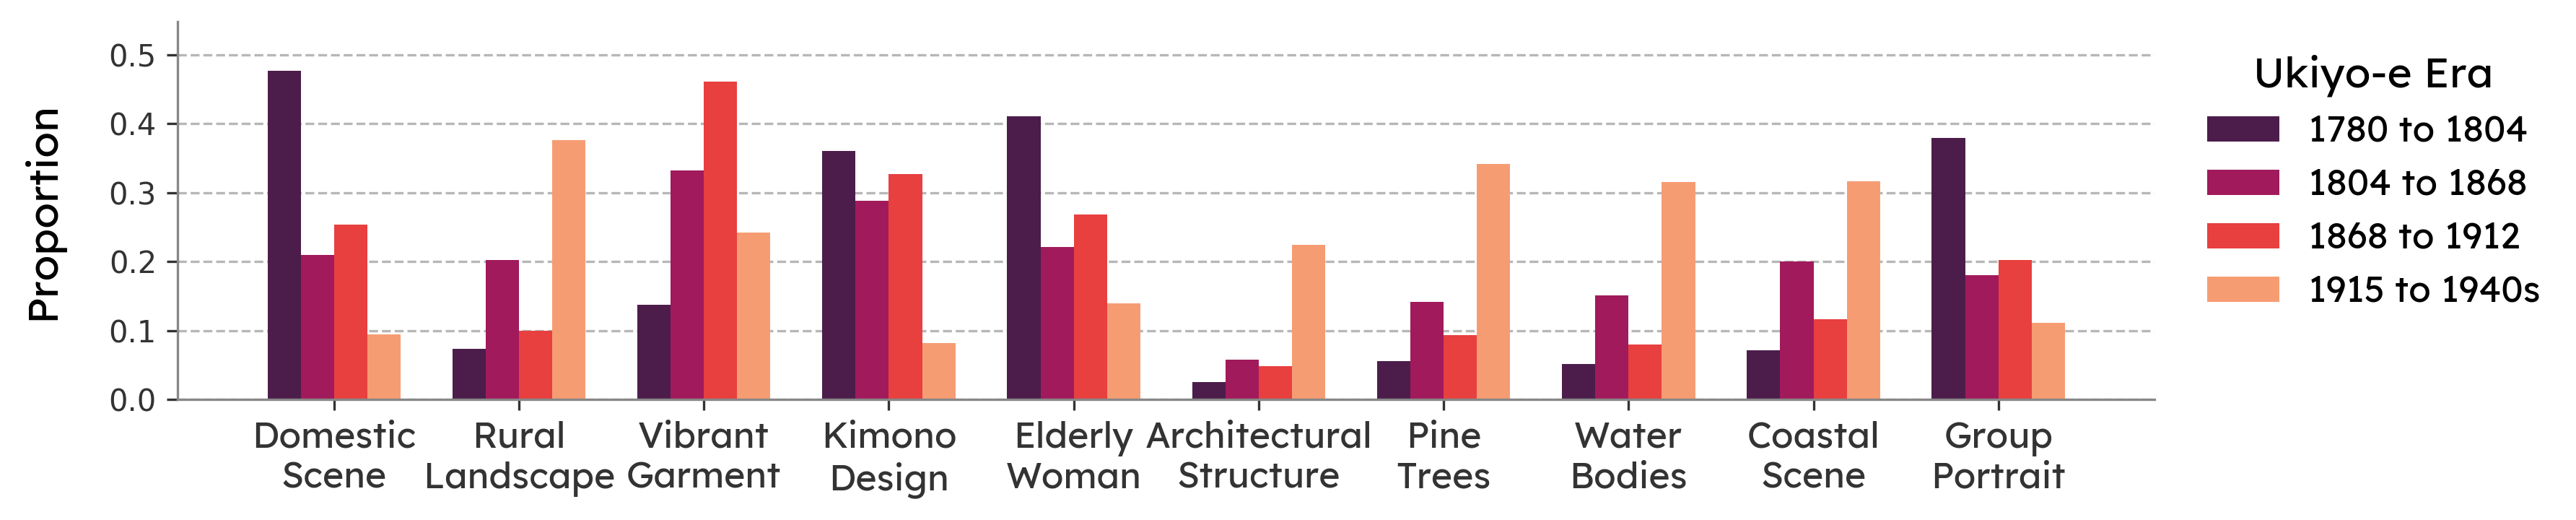

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import random
import textwrap
import seaborn as sns
import matplotlib.font_manager as fm

regular_font_path = 'data/assets/fonts/Lexend-Regular.ttf'
bold_font_path = 'data/assets/fonts/Lexend-Bold.ttf'

lexend_regular = fm.FontProperties(fname=regular_font_path, size=12)
lexend_bold = fm.FontProperties(fname=bold_font_path, size=12)
lexend_title = fm.FontProperties(fname=regular_font_path, size=14)

# --- 0. Mock Data Generation (to make S1 runnable) ---
# This section creates placeholder data that S1 can process.

era_order = [
    #"Birth of Full-Color Printing (1740s to 1780s)",
    #"Early Ukiyo-e (Early-Mid 1700s)",
    "Golden Age of Ukiyo-e (1780 to 1804)",
    "Popularization of Woodblock Printing (1804 to 1868)",
    "Meiji Period (1868 to 1912)",
    "Shin Hanga and Sosaku Hanga Movements (1915 to 1940s)",
    #"Modern and Contemporary (1950s to Now)"
]

print("--- Mock data generated. Running S1. ---")

# --- S1: Constructing the Pandas DataFrame (Unchanged) ---

cluster_id_to_summary = dict()
cluster_id_to_mode = dict()

for _, row in cluster_annotations.iterrows():
    cluster_id_to_summary[str(row["cluster_id"])] = row["llm_summary"]
    cluster_id_to_mode[str(row["cluster_id"])] = row["llm_classification"]

table = era_cluster_id_ratio_df.pivot(index="cluster_id", columns="era", values="ratio")
#table = table[era_order]
# Add column with variance of the ratios
table["variance"] = table.var(axis=1)
table["mean"] = table[era_order].mean(axis=1)
# Remove rows with mean > 0.5 (mean is already low, but we keep the logic)
table = table[table["mean"] <= 0.3]
# Add column with cluster summary
table["summary"] = [cluster_id_to_summary[cluster_id] for cluster_id in table.index]
# Add column with cluster mode
table["mode"] = [cluster_id_to_mode[cluster_id] for cluster_id in table.index]
# Remove rows with mode = "abstract"
table = table[table["mode"] != "abstract"]
# We apply the sorting and head(10) in the S2 section
# final_table = table.sort_values(by="variance", ascending=False).head(10)
# print(final_table)

# Filter columns not in era_order or not (variance, mean, summary, mode)
table = table[list(era_order) + ["variance", "mean", "summary", "mode"]]

print("--- S1 complete. Running adapted S2. ---")

# --- S2: Adapted Plotting Script ---

# 1. Create the DataFrame to plot
# This line connects S1 to S2
df = table.sort_values(by="variance", ascending=False).head(10)

# --- 2. Plotting Preparation ---

# Get the labels for the x-axis (wrapped for readability)
labels = [textwrap.fill(l, 25) for l in df['summary']]

# Get the data for each of the 7 groups (eras)
data_to_plot = [df[era] for era in era_order]

# Create shorter, wrapped labels for the legend
data_labels = [textwrap.fill(l.split("(")[1].rstrip(")"), 20) for l in era_order]

# Set up x-axis positions for the groups
x = np.arange(len(labels))  # the label locations
n_groups = len(era_order)   # Number of eras (7)
width = 0.18                # Reduced width for 7 bars

# Calculate the position for each bar in a group
# This formula generalizes the positioning from S2
positions = [x + (i - (n_groups - 1) / 2) * width for i in range(n_groups)]

# Get a clean color scheme (using 'tab10' colormap)
#colors = plt.cm.get_cmap('tab10', 10)
colors = sns.color_palette("rocket", 4)

# --- 3. Create the Matplotlib Plot ---

# Set a figure size that will accommodate the labels and legend
# Adjusted from S2's (12, 2.5) to (18, 8) for 7 data groups and long labels
fig, ax = plt.subplots(figsize=(12, 2.5), dpi=300)

# Add each bar group
for i in range(n_groups):
    ax.bar(
        positions[i],
        data_to_plot[i],
        width,
        label=data_labels[i],
        color=colors[i]
    )

# --- 4. Style the Plot for a Clean, Scientific Look ---

ax.set_ylabel('Proportion', fontproperties=lexend_title, labelpad=15)

# Set the x-axis ticks and labels
ax.set_xticks(x)
labels = [label.replace(" ", "\n") for label in labels]
ax.set_xticklabels(labels, rotation=0, ha='center', fontproperties=lexend_regular) # No rotation needed

# Set y-axis limits to give some space at the top
# Adjusted to use the era_order columns for max calculation
ax.set_ylim(0, df[era_order].max().max() * 1.15)

# Add a legend
# We place it outside the plot area to keep the chart clean
ax.legend(
    title='Ukiyo-e Era',
    prop=lexend_regular,        # Use 'prop' for the item font
    title_fontproperties=lexend_title, # Use this for the title font
    loc='upper left',
    bbox_to_anchor=(1.01, 1), # Positioned just outside the plot
    frameon=False
)

# Add a horizontal grid for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#888888')
ax.set_axisbelow(True) # Ensure grid is behind the bars

# Remove the top and right spines (borders)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

# Set tick colors
ax.tick_params(axis='x', colors='#333333')
ax.tick_params(axis='y', colors='#333333')

# Adjust layout to prevent labels from being cut off
# This is crucial for the external legend and wrapped labels
plt.tight_layout()

# Display the plot
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/ukiyoe_era_composition.pdf", dpi=300, bbox_inches="tight", format="pdf")
print("--- Plot saved to figures/ukiyoe_era_composition.pdf ---")
plt.show()


In [ ]:
with jsonlines.open("data/application/ukiyoe/captions.jsonl") as reader:
    captions_by_id = {line["id"]: line["document"] for line in reader}

Era: Popularization of Woodblock Printing (1804 to 1868)

Group Portrait: 0.0992
Intimate Interaction: 0.0660
Daily Life Scene: 0.0628
Domestic Interior: 0.0522
Kimono Garment: 0.0512
Textile Patterns: 0.0457
Elaborate Attire: 0.0441
Architectural Form: 0.0386
Kimono Attire: 0.0361
Rural Life: 0.0354
Elegant Kimono: 0.0300
Social Gathering: 0.0300
Kimono Design: 0.0264
Theatrical Performance: 0.0262
Elderly Woman: 0.0254
Architectural Setting: 0.0185
Theatrical Performance: 0.0167
Traditional Attire: 0.0167
Japanese Kimono: 0.0163


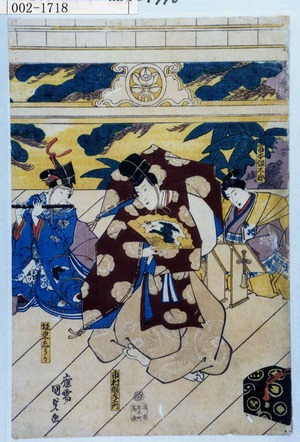

In [ ]:
import random
from PIL import Image

sample_idx = random.randint(0, theta.shape[0]-1)
img_id = annotations.iloc[sample_idx]["img"]

# Load image
image_path = "data/assets/ukiyoe/images/" + img_id
img = Image.open(image_path)

# Load caption
caption = captions_by_id[img_id]
#print(caption)
#print()

era = annotations.iloc[sample_idx]["era"]
print(f"Era: {era}")
print()

# Load topics
topic_weights = defaultdict(float)
theta_row = theta.getrow(sample_idx)
for feature_idx in theta_row.nonzero()[1]:
    topic = feature_idx_to_cluster[feature_idx]
    topic_weights[topic] += theta_row[0, feature_idx].item()

# Print topic weights
for topic, weight in sorted(topic_weights.items(), key=lambda x: x[1], reverse=True):
    summary = cluster_id_to_summary[topic]
    mode = cluster_id_to_mode[topic]
    if mode == "abstract":
        continue
    print(f"{summary}: {weight:.4f}")

img


In [ ]:
caption

"The image is a Japanese woodblock print depicting a serene winter scene at a lakeside. The foreground features snow-covered boats moored along a wooden railing, with one boat prominently in the lower right corner. The boats are detailed with visible ropes and oars, indicating their use for fishing or transportation. In the midground, a person is seated in a small boat, rowing across the calm, reflective water, which is dotted with snowflakes, suggesting ongoing snowfall. The background showcases a traditional Japanese building with a steeply pitched roof, partially obscured by snow, indicative of a lakeside house or a small inn. The building's architecture, with its wooden structure and large windows, is typical of historical Japanese design. The distant shoreline is faintly visible, adding depth to the composition. The sky is filled with falling snow, creating a textured pattern across the entire scene. In the lower left corner, there is a small circular seal, likely the artist's sig